In [1]:
import numpy as np
import scipy.sparse as sp
import networkx as nx
import random

In [2]:
class NUADM_ID:
    def __init__(self, GID0, GID1, GID2):
        aux = GID2[GID1]
        self.mapping = [GID1, aux]
        self.index_atual = 0
        self.ids = None # 
        self.id_NUADM = None
        self.num_volumes = [len(GID0), max(GID1) + 1, max(GID2) + 1]
        self.get_index_vector = GID0
        self.operator_index = np.arange(self.num_volumes[0])
        self.GID_1 = GID1
        self.GID_2 = GID2
        self.levels = len(self.mapping) + 1
        self.mesh = None

    def generate_ids(self, level_vector):
            self.index_atual = 0
            # inicializando vetor de ids NU-ADM
            self.id_NUADM = np.full(self.num_volumes[0], -1)
            self.ids = [np.full(self.num_volumes[i], -1) for i in range(1, self.levels)]
            print('ids initialized')
            
            index_0 = self.get_index_vector[level_vector == 0]
            self.id_NUADM[index_0] = np.arange(len(index_0))
            self.index_atual += len(index_0)

            for level in range(1, self.levels):
                index_level = self.get_index_vector[level_vector == level]
                primal_index = np.unique(self.mapping[level - 1][index_level])
                self.ids[level - 1][primal_index] = np.arange(self.index_atual, self.index_atual + len(primal_index))
                self.id_NUADM[index_level] = self.ids[level - 1][self.mapping[level - 1][index_level]]
                self.index_atual += len(primal_index)

    # Gera o operador de prolongamento entre dois níveis, para n níveis
    def generate_operator(self, lines_operator, columns_operator, values_operator, level_vector, primal_vertex):
        new_lines = []
        new_columns = []
        new_values = []
        new_level_vector = level_vector.copy()

        self.mesh = [self.operator_index]
        ids = [self.operator_index]

        for i in range(self.levels - 1):
            new_level_vector[level_vector > i] = i + 1
            self.generate_ids(new_level_vector)
            self.mesh.append(self.id_NUADM)
            ids.append(self.ids[i].copy())
            
            first_mask = new_level_vector <= i

            lines_0 = self.mesh[i][first_mask]
            columns_0 = self.id_NUADM[first_mask]
            values_0 = np.ones_like(lines_0)

            # Ajusta os ids que não foram usados para o mesmo do vértice da grossa anterior sem afetar o resto do código (o que importa já foi salvo)
            self.ids[0][self.ids[0] == -1] = self.id_NUADM[primal_vertex[0][self.ids[0] == -1]]
            for j in range(i):
                self.ids[j+1][self.ids[j+1] == -1] = self.ids[j][primal_vertex[j+1][self.ids[j+1] == -1]]
            # for j in range(len(self.ids)):
            #     print(self.ids[j])

            if i == 0:
                mask = new_level_vector[lines_operator[i]] > i
                lines_1 = lines_operator[i][mask]
                columns_1 = self.ids[i][columns_operator[i][mask]]
                # columns_1[columns_1 == -1] = self.id_NUADM[primal_vertex[i][columns_operator[i][columns_1 == -1]]]
                values_1 = values_operator[i][mask]
                
            else:
                # Exemplo para i = 1:
                # ids[i] = ids NUADM dos elementos da grossa 1 usando o level_vector com level máximo = 1 (iteração anterior: i = 0)
                # self.ids[i-1] = ids_NUADM dos elementos da grossa 1 usando o level_vector com level máximo = 2
                # aux = elementos da grossa 1 que fazem parte de um elemento da grossa 2 que possui um id NUADM)
                aux = np.isin(self.GID_2, np.arange(max(self.GID_2) + 1)[ids[i+1] > -1])
                # print(aux)

                mask = aux[lines_operator[i]]
                lines_1 = ids[i][lines_operator[i][mask]]
                columns_1 = self.ids[i][columns_operator[i][mask]]
                values_1 = values_operator[i][mask]

            new_lines.append(np.concatenate((lines_0, lines_1)))
            new_columns.append(np.concatenate((columns_0, columns_1)))
            new_values.append(np.concatenate((values_0, values_1)))

        return new_lines, new_columns, new_values

In [3]:
def generate_adj_cent(H, V, A):
    nb=[V, H, A]
    lb=[1, 1, 1]
    sp=[0.0, 0.0, 0.0]
    ms = np.mgrid[sp[0]+0.5*lb[0]:sp[0]+(nb[0]+0.5)*lb[0]:lb[0],
                  sp[1]+0.5*lb[1]:sp[1]+(nb[1]+0.5)*lb[1]:lb[1],
                  sp[2]+0.5*lb[2]:sp[2]+(nb[2]+0.5)*lb[2]:lb[2]]

    ms = ms.flatten()
    centroids = ms.reshape(3,int(ms.size/3)).T
    ############
    # ijk0 = np.array([centroids[:, 0]//lb[0], centroids[:, 1]//lb[1], centroids[:, 2]//lb[2]])
    # ee = ijk0[0] + ijk0[1]*nb[0] + ijk0[2]*nb[0]*nb[1] #60 3600
    # # import pdb; pdb.set_trace()
    # centroids=centroids[ee.astype(int)]
    # ##########
    GID_0 = np.arange(H*V*A)
    adjs0 = np.tile(GID_0,(np.array(nb)>1).sum())
    adjs1 = np.array([])
    sx=1
    # sy=1
    if nb[1]>1:
        adjs1 = np.concatenate([adjs1, GID_0+1])
        sy=nb[1]
    if nb[0]>1:
        adjs1 = np.concatenate([adjs1, GID_0+sy])
        # sy=nb[1]
    if nb[2]>1:
        adjs1 = np.concatenate([adjs1, GID_0+sx*sy])
    adjs1=adjs1.astype(int)
    adjs=np.vstack([adjs0,adjs1]).T
    adjs=adjs[adjs.max(axis=1)<=GID_0.max()]
    dif=abs(centroids[adjs[:,0]]-centroids[adjs[:,1]])
    adjacencies=adjs[((dif>0).sum(axis=1)==1) & ((dif<=lb).sum(axis=1)==3)]
    areas=np.array([lb[1]*lb[2], lb[0]*lb[2], lb[0]*lb[1]])
    areas=np.tile(areas,len(adjacencies)).reshape(len(adjacencies),3)[abs(centroids[adjacencies[:,0]]-centroids[adjacencies[:,1]])>0]
    return centroids, adjacencies

def label_levels_from_fines(adjs, fines, max_level):
    gids = np.arange(adjs.max() + 1)
    levels = np.full_like(gids, max_level + 1)  # valores default maiores que o nível máximo
    levels[fines] = 0  # nível inicial (fines)

    current_level = 0
    current_front = set(fines)

    while current_level < max_level:
        # Encontra adjacências onde pelo menos um vértice está no nível atual
        mask = np.isin(adjs[:, 0], list(current_front)) | np.isin(adjs[:, 1], list(current_front))
        neighbors = adjs[mask].flatten()

        # Remove os que já foram rotulados com nível menor ou igual
        next_front = np.setdiff1d(neighbors, np.where(levels <= current_level)[0], assume_unique=False)

        # Atribui novo nível
        levels[next_front] = current_level + 1

        # Prepara próxima iteração
        current_front = set(next_front)
        current_level += 1

        if len(current_front) == 0:
            break  # Não há mais vizinhos para expandir

    return levels

def get_level_vector(H, V, A):
    print(f'Generating level_vector')
    fines = np.random.choice(H*V*A, size=round(H*V*A * 0.1), replace=False) # 10% dos volumes são finos
    centroids, adjs = generate_adj_cent(H, V, A)
    gids = np.arange(H*V*A)
    level_vector = label_levels_from_fines(adjs, gids[fines],1) # 5 níveis
    return level_vector

In [4]:
def get_vertices(OP, GID_1):
    # OP = [lines, cols, data]
    pos = GID_1[OP[0]] == OP[1]
    phis = OP[2][pos]

    nc, nl = OP[1].max() + 1, OP[0].max() + 1

    mat = sp.csc_matrix((phis, (OP[1][pos], OP[0][pos])), shape=(nc, nl))

    # Encontra o índice da coluna (ID fine) que contém o peso máximo para cada linha (ID coarse)
    max_indices = mat.argmax(axis=1)

    # Converte numpy.matrix para array 1D:
    vertices = np.asarray(max_indices).ravel()

    # IDs coarse:
    coarses = np.arange(nc)

    return vertices, coarses


In [5]:
def elemento_central(grosso_id, map_fino_grosso, G):
    cluster = np.where(map_fino_grosso == grosso_id)[0]
    subG = G.subgraph(cluster)

    centralidade = nx.closeness_centrality(subG)
    return max(centralidade, key=centralidade.get)

def get_center_vertices(GID, G):
    center_vertices = []
    num_coarse = max(GID) + 1
    for coarse_id in range(num_coarse):
        center_vertex = elemento_central(coarse_id, GID, G)
        center_vertices.append(center_vertex)
    return np.array(center_vertices)


In [6]:
H = 100
V = 100
A = 1
N = H * V * A

data = np.load("arquivos/A_data.npy")
cols = np.load("arquivos/A_cols.npy")
rows = np.load("arquivos/A_lines.npy")

T = sp.coo_matrix((data, (rows, cols)), shape=(N, N)).tocsr()

G = nx.Graph()
G.add_nodes_from(range(N))

rows_nz, cols_nz = T.nonzero()
for i, j in zip(rows_nz, cols_nz):
    if i != j:
        G.add_edge(i, j)


# mesh = MultiLevel_NUADM(nX_all=[5, 7], nY_all=[10, 4], nZ_all=[1, 1], levels=3)
# centroids, _ = generate_adj_cent(H, V, A)
# mesh.generate_levels(centroids)

GID_2 = np.load('arquivos/primal_id_level2.npy')

GID_1 = np.load('arquivos/primal_id_level1.npy')

GID_0 = np.arange(GID_1.shape[0])

lines_operator_0 = np.load('arquivos/OP_level1_lines.npy')

columns_operator_0 = np.load('arquivos/OP_level1_cols.npy')
                       
values_operator_0 = np.load('arquivos/OP_level1_data.npy')

lines_operator_1 = np.load('arquivos/OP_level2_lines.npy')

columns_operator_1 = np.load('arquivos/OP_level2_cols.npy')

values_operator_1 = np.load('arquivos/OP_level2_data.npy')

level_vector = get_level_vector(H, V, A)

primal_vertex = []

# vertices, coarse = get_vertices([lines_operator_0, columns_operator_0, values_operator_0], GID_1)
# vert = np.ones_like(coarse)
# vert[coarse] = vertices
# primal_vertex.append(vert)

# vertices, coarse = get_vertices([lines_operator_1, columns_operator_1, values_operator_1], GID_2)
# vert = np.ones_like(coarse)
# vert[coarse] = vertices
# primal_vertex.append(vert)

## Método Sugerido por João (Centralidade)

vertices = get_center_vertices(GID_1, G)
primal_vertex.append(vertices)

vertices = get_center_vertices(GID_2[GID_1], G)
vertices = GID_1[vertices]
primal_vertex.append(vertices)

print(primal_vertex)

# dual_0 = np.array([2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2,
#                    3, 2, 2, 2, 3, 2, 2, 3, 2, 2, 3, 2, 2, 3, 2, 2, 2, 3,
#                    2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2])

# dual_1 = np.array([3, 2, 3, 2, 2, 3])

# grossa_0 = np.unique(GID_1)
# grossa_1 = np.unique(GID_2)

# grossa = [GID_1, GID_2]
# grossa_unique = [grossa_0, grossa_1]
# dual = [dual_0, dual_1]

# # Funciona apenas para o caso de 2 níveis
# # Primal vetex são os elementos da malha fina que são vértices da malha dual, onde cada vertice é relacionado com um elemento da malha grossa
# primal_vertex = []
# for i in range(len(grossa_unique)):
#     aux = np.empty(grossa_unique[i].shape[0], dtype=int)
#     aux[grossa[i][(dual[i] == 3)]] = np.arange(len(dual[i]))[dual[i] == 3]
#     # for i in range(len(primal_vertex)):
#     #     aux = primal_vertex[i][aux]
#     primal_vertex.append(aux)

# print(primal_vertex)


# # primal_vertex_1 = np.empty(grossa_1.shape[0], dtype=int)
# # primal_vertex_1[GID_2[(dual_1 == 3)]] = np.arange(len(dual_1))[dual_1 == 3]
# # print(primal_vertex_1)

# new_operator = sp.csr_matrix((values_operator_0, (lines_operator_0, columns_operator_0)))
# file = open('operador_test.txt', 'w')
# operator = new_operator.toarray()
# for i in operator:
#     for j in i:
#         file.writelines(f'{j:.2f}  ')
#     file.writelines(f'\n')
# file.close()


Generating level_vector
[array([3158, 2752, 3250, 4049, 3855, 4455, 4262, 4274, 4268, 3373, 3064,
       3566, 2362, 2367, 2472, 2149, 1956, 1553,  448,  554, 1151,  360,
        466, 1161, 1467,  486,  492,  597, 1396, 1188, 1688,  571,  278,
        778, 1581, 1775, 1274, 2093, 2697, 2691, 2586, 2480, 3080, 3579,
       4285, 4280, 4297, 4291, 3589, 3496, 2804, 3403, 3408, 4303, 4214,
       4209, 4120, 2913, 3517, 2620, 3223, 2828,  219, 1015,  921, 1915,
       1821, 1926,  402,  709,  209, 2203, 2109, 1403, 1409, 2043, 2642,
       3141, 2833, 2132, 1937, 4438, 4144, 3739, 4225, 3632, 4231, 4995,
       5079, 4987, 5070, 5053, 5062,  240,  741, 1343, 1029, 1334,  426,
        333, 7402, 6603, 6004, 6809, 7514, 7607, 5919, 6718, 7320, 5506,
       5614, 6212, 8703, 8611, 8107, 9502, 9209, 9711, 9618, 9423, 9529,
       8719, 8118, 8024, 8727, 5824, 5828, 5833, 6933, 6628, 7327, 6939,
       6944, 6749, 6240, 5646, 5639, 9654, 9549, 9644, 8733, 9736, 9237,
       7831, 7738, 8338, 7

In [7]:
# GID_2 = np.array([0, 0, 1, 1, 2, 2])

# GID_1 = np.array([0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5, 
#                   0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5, 
#                   0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5])

# GID_0 = np.arange(54)

# # level_vector = np.array([0, 0, 0, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 0, 0, 0,
# #                          0, 0, 0, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 0, 0, 0,
# #                          0, 0, 0, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 0, 0, 0])

# lines_operator_0 = np.array([0 , 1 , 1 , 2 , 2 , 3 , 3 , 4 , 5 , 5 , 6 , 6 , 7 , 8 , 8 , 9 , 9 , 10, 11, 11, 12, 12, 13, 14, 14, 15, 15, 16, 16, 17,
#                              18, 19, 19, 20, 20, 21, 21, 22, 23, 23, 24, 24, 25, 26, 26, 27, 27, 28, 29, 29, 30, 30, 31, 32, 32, 33, 33, 34, 34, 35,
#                              36, 37, 37, 38, 38, 39, 39, 40, 41, 41, 42, 42, 43, 44, 44, 45, 45, 46, 47, 47, 48, 48, 49, 50, 50, 51, 51, 52, 52, 53])

# columns_operator_0 = np.array([0, 0, 1, 0, 1, 0, 1, 1, 1, 2, 1, 2, 2, 2, 3, 2, 3, 3, 3, 4, 3, 4, 4, 4, 5, 4, 5, 4, 5, 5,
#                                0, 0, 1, 0, 1, 0, 1, 1, 1, 2, 1, 2, 2, 2, 3, 2, 3, 3, 3, 4, 3, 4, 4, 4, 5, 4, 5, 4, 5, 5,
#                                0, 0, 1, 0, 1, 0, 1, 1, 1, 2, 1, 2, 2, 2, 3, 2, 3, 3, 3, 4, 3, 4, 4, 4, 5, 4, 5, 4, 5, 5])
                       
# values_operator_0 = np.array([1, 0.75, 0.25, 0.5, 0.5, 0.25, 0.75, 1, 0.75, 0.25, 0.25, 0.75, 1, 0.75, 0.25, 0.25, 0.75, 1, 0.75, 0.25, 0.25, 0.75, 1, 0.75, 0.25, 0.5, 0.5, 0.25, 0.75, 1,
#                               1, 0.75, 0.25, 0.5, 0.5, 0.25, 0.75, 1, 0.75, 0.25, 0.25, 0.75, 1, 0.75, 0.25, 0.25, 0.75, 1, 0.75, 0.25, 0.25, 0.75, 1, 0.75, 0.25, 0.5, 0.5, 0.25, 0.75, 1,
#                               1, 0.75, 0.25, 0.5, 0.5, 0.25, 0.75, 1, 0.75, 0.25, 0.25, 0.75, 1, 0.75, 0.25, 0.25, 0.75, 1, 0.75, 0.25, 0.25, 0.75, 1, 0.75, 0.25, 0.5, 0.5, 0.25, 0.75, 1])

# lines_operator_1 = np.array([0, 1, 1, 2, 3, 3, 4, 4, 5])

# columns_operator_1 = np.array([0, 0, 1, 1, 1, 2, 1, 2, 2])

# values_operator_1 = np.array([1, 0.5, 0.5, 1, 0.75, 0.25, 0.25, 0.75, 1])

# # dual_0 = np.array([2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2,
# #                    3, 2, 2, 2, 3, 2, 2, 3, 2, 2, 3, 2, 2, 3, 2, 2, 2, 3,
# #                    2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2])

# # dual_1 = np.array([3, 2, 3, 2, 2, 3])

# # grossa_0 = np.unique(GID_1)
# # grossa_1 = np.unique(GID_2)

# # grossa = [GID_1, GID_2]
# # grossa_unique = [grossa_0, grossa_1]
# # dual = [dual_0, dual_1]

# # # Funciona apenas para o caso de 2 níveis
# # # Primal vetex são os elementos da malha fina que são vértices da malha dual, onde cada vertice é relacionado com um elemento da malha grossa
# # primal_vertex = []
# # for i in range(len(grossa_unique)):
# #     aux = np.empty(grossa_unique[i].shape[0], dtype=int)
# #     aux[grossa[i][(dual[i] == 3)]] = np.arange(len(dual[i]))[dual[i] == 3]
# #     # for i in range(len(primal_vertex)):
# #     #     aux = primal_vertex[i][aux]
# #     primal_vertex.append(aux)

# # print(primal_vertex)

# primal_vertex = []

# vertices, coarse = get_vertices([lines_operator_0, columns_operator_0, values_operator_0], GID_1)
# vert = np.ones_like(coarse)
# vert[coarse] = vertices
# primal_vertex.append(vert)

# vertices, coarse = get_vertices([lines_operator_1, columns_operator_1, values_operator_1], GID_2)
# vert = np.ones_like(coarse)
# vert[coarse] = vertices
# primal_vertex.append(vert)

# print(primal_vertex)

In [8]:
sla = NUADM_ID(GID_0, GID_1, GID_2)
sla.generate_ids(level_vector)
# for i in range(3):
#     for j in range(18):
#         num = sla.id_NUADM[i*18+j]
#         if num / 10 < 1:
#             print(f' {sla.id_NUADM[i*18+j]}', end=' ')
#         else:
#             print(f'{sla.id_NUADM[i*18+j]}', end=' ')
#     print()
lines_op = [lines_operator_0, lines_operator_1]
columns_op = [columns_operator_0, columns_operator_1]
values_op = [values_operator_0, values_operator_1]
# primal_vertex = [primal_vertex_0, primal_vertex_1]
new_lines, new_columns, new_values = sla.generate_operator(lines_op, columns_op, values_op, level_vector, primal_vertex)

# ids_NUADM:
#  0  1  2 18 18 18 20 20 20 20 20 20 19 19 19  3  4  5
#  6  7  8 18 18 18 20 20 20 20 20 20 19 19 19  9 10 11
# 12 13 14 18 18 18 20 20 20 20 20 20 19 19 19 15 16 17


# 17 17 17 17 17 17 18 18 18 14 18 18  0 15 19 16  1 16 
# 17 11  2 17 17 12 18 13 18 14  3 14 15  4 15 16  5 16 
# 17 11 17 12  6 12 13 13 18  7 14 14  8 15  9 16 16 10


ids initialized
ids initialized
ids initialized


In [9]:
i = 1

arr = np.unique(np.column_stack((new_lines[i], new_columns[i], new_values[i])), axis=0)
l = arr[:, 0].astype(np.int32)
c = arr[:, 1].astype(np.int32)
d = arr[:, 2]

In [10]:
# import matplotlib.pyplot as plt
# from scipy.sparse import csr_matrix
# import numpy as np

# # ===================================================================
# # PASSO 1: CARREGAMENTO DA SUA MATRIZ CSR
# # *d, l, c* são os arrays de dados, linhas e colunas que você está usando.
# # ===================================================================

# # Esta linha deve estar no seu script, onde d, l, e c já estão definidos:
# matriz_esparsa = csr_matrix((d, (l, c))) 

# # As dimensões são necessárias para configurar os limites do gráfico
# M, N = matriz_esparsa.shape

# # ===================================================================
# # PASSO 2: CÓDIGO DE PLOTAGEM PARA VALIDAÇÃO VISUAL
# # ===================================================================

# plt.figure(figsize=(12, 10))

# # 1. Gráfico de Dispersão (Scatter Plot)
# #   - X-axis (c): Colunas
# #   - Y-axis (l): Linhas
# #   - Color (c=d): A cor de cada ponto é mapeada para o valor do elemento (d)
# #   - markersize (s): 1 é ideal para matrizes muito grandes
# scatter = plt.scatter(
#     c, 
#     l, 
#     c=d, 
#     cmap='viridis',  # 'viridis' ou 'coolwarm' (se tiver valores positivos/negativos)
#     s=5
# )

# # 2. Configurações para Imagem de Matriz
# plt.title(f'Visualização de Valores Não-Zero da Matriz CSR ({M}x{N})', fontsize=16)
# plt.xlabel('Colunas')
# plt.ylabel('Linhas')

# # Inverte o eixo Y para que a linha 0 (topo da matriz) apareça no topo do gráfico
# plt.gca().invert_yaxis()

# # Define os limites do gráfico para corresponder às dimensões da matriz
# plt.xlim(-0.5, N + 0.5)
# plt.ylim(M + 0.5, -0.5)

# # 3. Barra de Cores para Validação
# # Adiciona a barra de cores (o "termômetro" do Heatmap)
# cbar = plt.colorbar(scatter)
# cbar.set_label('Magnitude dos Elementos Não-Zero (d)', fontsize=12)

# # Oculta os rótulos de tick se a matriz for grande demais
# if M > 500 or N > 500:
#     plt.xticks([])
#     plt.yticks([])

# # 4. Exibir o Gráfico
# plt.tight_layout()
# plt.show()

In [11]:
i = 0
arr = np.unique(np.column_stack((new_lines[i], new_columns[i], new_values[i])), axis=0)
l = arr[:, 0].astype(np.int32)
c = arr[:, 1].astype(np.int32)
d = arr[:, 2]

aux_op = sp.csr_matrix((d, (l.astype(int), c.astype(int))), shape = (int(l.max()+1), int(c.max()+1)), dtype=np.float32)

# FB=aux_op[:,v].toarray().transpose()[0]
# grid.cell_data["NEW_OP"] = FB

i = 1
arr = np.unique(np.column_stack((new_lines[i], new_columns[i], new_values[i])), axis=0)
l = arr[:, 0].astype(np.int32)
c = arr[:, 1].astype(np.int32)
d = arr[:, 2]

aux1_op=sp.csr_matrix((d, (l.astype(int), c.astype(int))), shape = (int(l.max()+1), int(c.max()+1)), dtype=np.float32)

new_op = aux_op @ aux1_op

In [27]:
import numpy as np
import gstools as gs
import pyvista as pv
import scipy.sparse as sp

def get_grid():
    ordem=[0, 1, 2]
    nb=np.array([nx, ny, nz])[ordem]+1
    lb=np.array([hx,hy,hz])[ordem]
    sp=np.array([0,0,0])
    grid = pv.ImageData()
    grid.dimensions = nb
    grid.origin = sp  # The bottom left corner of the data set
    grid.spacing = lb  # These are the cell sizes along each axis
    return grid
# Dimensões SPE10
# nx, ny, nz = 60, 220, 85
# Lx, Ly, Lz = 1200.0, 2200.0, 850.0
nx, ny, nz = 100, 100, 1
Lx, Ly, Lz = 100, 100, 1
hx, hy, hz = Lx/nx, Ly/ny, Lz/nz

x = np.linspace(hx/2, Lx - hx/2, nx)
y = np.linspace(hy/2, Ly - hy/2, ny)
z = np.linspace(hz/2, Lz - hz/2, nz)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Modelo geoestatístico
model = gs.Exponential(
    dim=3,
    var=1.0,
    len_scale=[300, 300, 3],
    anis=[1.0, 1.0, 0.05],
)

srf = gs.SRF(model, seed=42)
log_k = srf((X, Y, Z))
log_k = 6 * (log_k - np.mean(log_k)) / np.std(log_k)
k = np.exp(log_k)  # mD

# Salvar como .txt
k_flat = k.flatten(order='F')
grid=get_grid()
centroids=np.array([X.flatten(),Y.flatten(),Z.flatten()]).T

# grid.cell_data["ks"] = np.log10(k_flat)
# l0,c0,d0=np.load('arquivos/op_132000_576.npy')
v = 1209
# op_ms=sp.csr_matrix((d0, (l0.astype(int), c0.astype(int))), shape = (int(l0.max()+1), int(c0.max()+1)), dtype=np.float32)
# FBms=op_ms[:,v].toarray().transpose()[0]

# grid.cell_data["OPms_"+str(v)] = FBms
# grid.cell_data["DUAL"] = dual[0]
grid.cell_data["levels"] = level_vector

print(new_op.shape)

FB=new_op[:,v].toarray().transpose()[0]
grid.cell_data["FINAL_OP"] = FB

# FB=aux_op[:,v].toarray().transpose()[0]
# grid.cell_data["OP_1"] = FB

FB=aux1_op[:,v].toarray().transpose()[0][sla.mesh[1]]
grid.cell_data["OP_2"] = FB

sum = np.sum(new_op.todense(), axis=1)
grid.cell_data["SUM_FINAL_OP"] = np.array(sum).flatten()

sum = np.sum(aux_op.todense(), axis=1)
grid.cell_data["SUM_OP_1"] = np.array(sum).flatten()

sum = np.sum(aux1_op.todense(), axis=1)[sla.mesh[1]]
grid.cell_data["SUM_OP_2"] = np.array(sum).flatten()

grid.cell_data["levels"] = level_vector

grid.cell_data["coarse_1"] = GID_1

grid.cell_data["coarse_2"] = GID_2[GID_1]

arr = np.zeros_like(GID_1)
arr[primal_vertex[0]] = 1
grid.cell_data["vertex_1"] = arr

arr = np.zeros_like(GID_1)
arr[np.isin(GID_1, primal_vertex[1])] = 1
grid.cell_data["vertex_2"] = arr

# grid.cell_data["ks"] = np.log10(k_flat)



grid.save('arquivos/results/gs_spe10.vtk') # ativar
# import pdb; pdb.set_trace()
# np.savetxt("permeabilidade_spe10_geoestatistica.txt", k_flat, fmt="%.6e")
# import pdb; pdb.set_trace()


(10000, 1210)


## Plot Matrizes


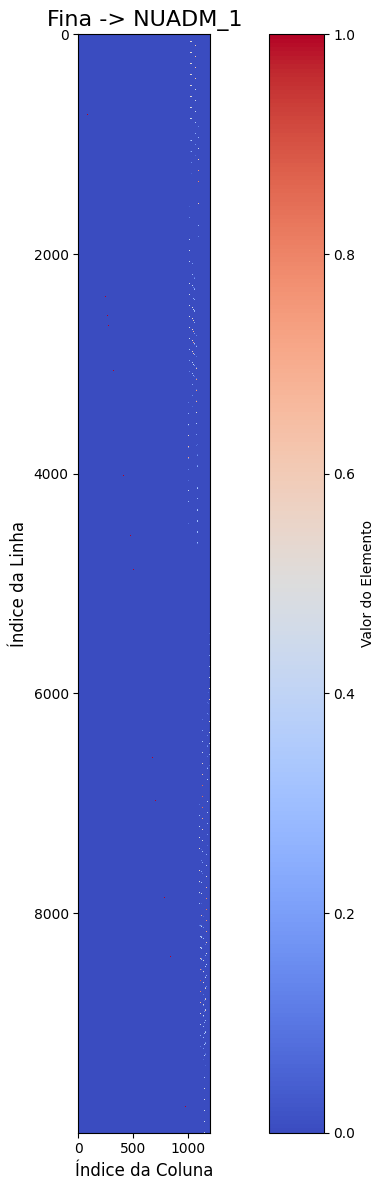

In [13]:
import matplotlib.pyplot as plt
import scipy.sparse as sp
import numpy as np

# Exemplo de matriz esparsa (caso queira testar)
# aux_op = sp.random(100, 100, density=0.05, format='csr', data_rvs=np.random.randn)

# Converter para densa (ou usar .toarray() para visualização)
matrix_dense = aux_op.toarray()

plt.figure(figsize=(12, 12))
plt.imshow(matrix_dense, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Valor do Elemento')

plt.title("Fina -> NUADM_1", fontsize=16)
plt.xlabel("Índice da Coluna", fontsize=12)
plt.ylabel("Índice da Linha", fontsize=12)
plt.tight_layout()
plt.show()


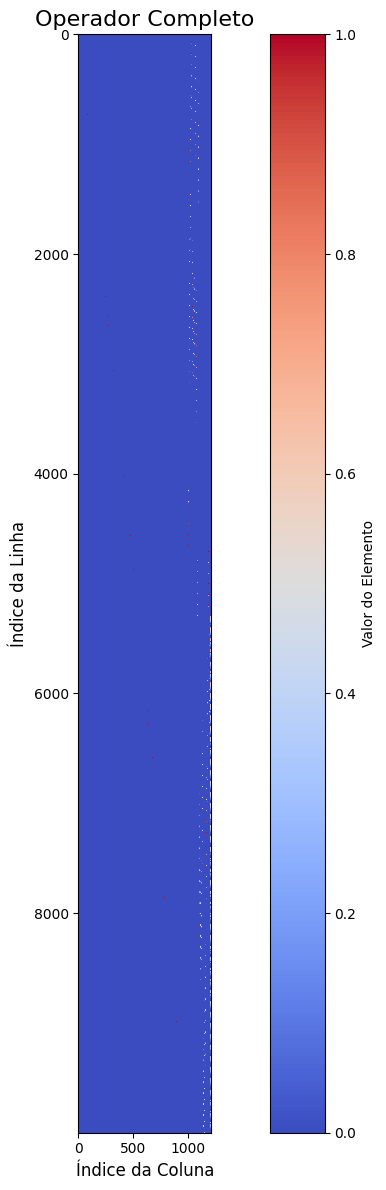

In [14]:
import matplotlib.pyplot as plt
import scipy.sparse as sp
import numpy as np

# Exemplo de matriz esparsa (caso queira testar)
# aux_op = sp.random(100, 100, density=0.05, format='csr', data_rvs=np.random.randn)

# Converter para densa (ou usar .toarray() para visualização)
matrix_dense = new_op.toarray()

plt.figure(figsize=(12, 12))
plt.imshow(matrix_dense, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Valor do Elemento')

plt.title("Operador Completo", fontsize=16)
plt.xlabel("Índice da Coluna", fontsize=12)
plt.ylabel("Índice da Linha", fontsize=12)
plt.tight_layout()
plt.show()


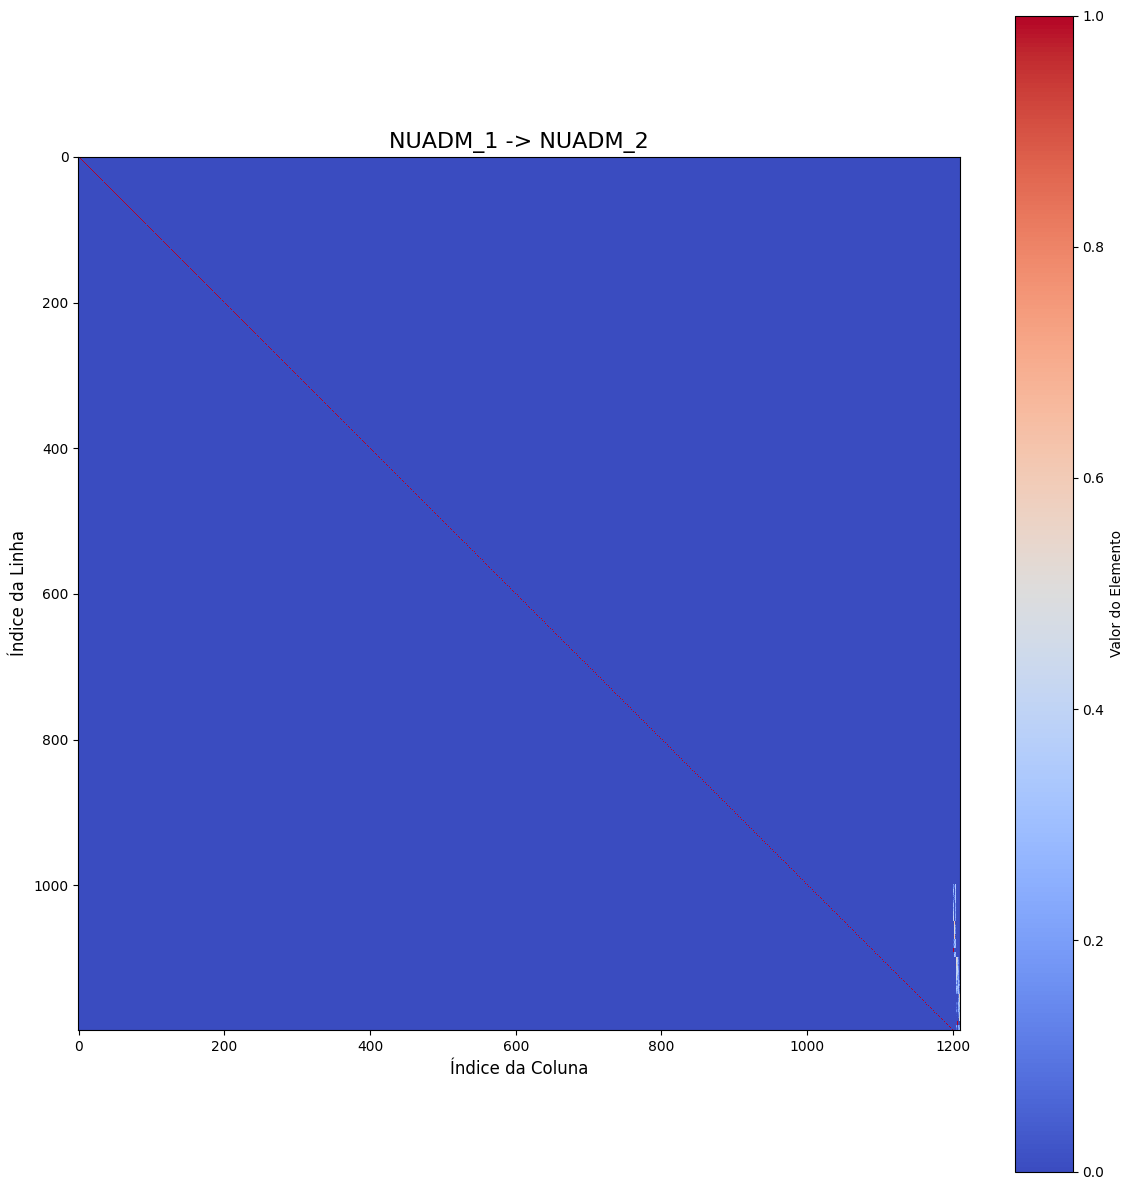

In [15]:
import matplotlib.pyplot as plt
import scipy.sparse as sp
import numpy as np

# Exemplo de matriz esparsa (caso queira testar)
# aux_op = sp.random(100, 100, density=0.05, format='csr', data_rvs=np.random.randn)

# Converter para densa (ou usar .toarray() para visualização)

aux1_op=sp.csr_matrix((d, (l, c)))
matrix_dense = aux1_op.toarray()

plt.figure(figsize=(12, 12))
plt.imshow(matrix_dense, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Valor do Elemento')

plt.title("NUADM_1 -> NUADM_2", fontsize=16)
plt.xlabel("Índice da Coluna", fontsize=12)
plt.ylabel("Índice da Linha", fontsize=12)
plt.tight_layout()
plt.show()


In [16]:
np.sum(new_op.todense(), axis=1)

matrix([[2.       ],
        [2.       ],
        [2.       ],
        ...,
        [2.       ],
        [1.9999999],
        [2.       ]], shape=(10000, 1), dtype=float32)